In [2]:
import geopandas as gpd
import pandas as pd
import numpy as np
import yaml

import matplotlib.pyplot as plt

from munch import munchify
import os

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

In [3]:
# load config
with open("cafo_iowa/config.yaml", "r") as file:
    config = munchify(yaml.safe_load(file))

In [4]:
# load data
# naip
fp = os.path.join(config.naip_shp.output_path, "04_quartered_buffer_tiles.feather")
naip_shp = gpd.read_feather(fp)

# permits
fp = os.path.join(config.permits.output_path)
permits = pd.read_csv(fp)

In [5]:
# join the permit data with the naip shapefile
permits = gpd.GeoDataFrame(
    permits, geometry=gpd.points_from_xy(permits.longitude, permits.latitude)
)
permits.set_crs(epsg=4326, inplace=True)
permits = permits.to_crs(naip_shp.crs)
gdf = gpd.sjoin(permits, naip_shp)

# set epsg to 4326, for labeling checking using google earth
# gdf.to_crs(epsg=4326, inplace=True)

There are 1 permits in tile m_4309552_nw_15_060_20210815_BL
Together, the facilities have 8499 animal units, of which 0 are swine animal units


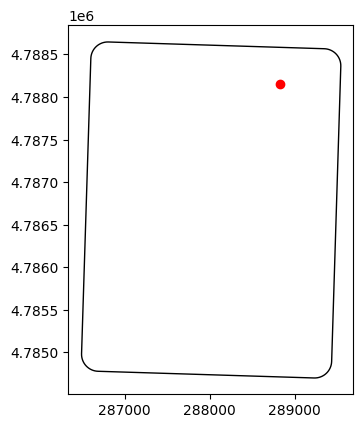

In [12]:
tile_ids = ["m_4309552_nw_15_060_20210815_BL"]

# for a given qt tile id, count the number of permits in the tile and then plot their location
for tile_id in tile_ids:
    print(
        f"There are {gdf.loc[gdf.qt_tile_id == tile_id].shape[0]} permits in tile {tile_id}"
    )
    print(
        f"Together, the facilities have {gdf.loc[gdf.qt_tile_id == tile_id].animal_units.sum()} animal units, of which {gdf.loc[gdf.qt_tile_id == tile_id].swine_animal_units.sum()} are swine animal units"
    )
    fig, ax = plt.subplots()
    naip_shp.loc[naip_shp.qt_tile_id == tile_id].plot(
        ax=ax, color="white", edgecolor="black"
    )
    gdf.loc[gdf.qt_tile_id == tile_id].plot(ax=ax, color="red")
    plt.show()
    print("\n\n\n")